In [1]:
# Cell 1 — imports & config
import os
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from joblib import dump, load

# plotting niceties
%matplotlib inline
sns.set(style="whitegrid")

# Base paths (adjust if your notebook lives elsewhere)
BASE = Path.cwd()  # assume running notebook at repo/backend or repo root; change if needed
LOG_FILE = BASE / 'logs' / 'events.log'
MODEL_DIR = BASE / 'backend' / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Log file:", LOG_FILE)
print("Model dir:", MODEL_DIR)


Log file: /Users/suryavardhanchaluvadi/Library/CloudStorage/OneDrive-Amritavishwavidyapeetham/B.Tech/Sem 5/ML/ML_hackathon/backend/logs/events.log
Model dir: /Users/suryavardhanchaluvadi/Library/CloudStorage/OneDrive-Amritavishwavidyapeetham/B.Tech/Sem 5/ML/ML_hackathon/backend/backend/models


In [2]:
# Cell 2 — load raw events
events = []
if LOG_FILE.exists():
    with open(LOG_FILE, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                events.append(json.loads(line))
            except Exception as e:
                # skip malformed lines
                print("Skipping bad line:", e)
else:
    raise FileNotFoundError(f"Log file not found at {LOG_FILE}")

print("Loaded events:", len(events))
# show first few
pd.DataFrame(events[:8])


Loaded events: 8766


,session_id,event,poi_id,poi_name,variant,audio_play_ratio,scroll_depth,time_on_card,image_views,reward,ts
0,762f4532-256a-4cae-8083-551ecf2b4917,poi_session_end,34,Chunchi Falls,text,0.076,0.082,46.85,0,0,1.760762e+09
1,762f4532-256a-4cae-8083-551ecf2b4917,poi_session_end,1,Bangalore Palace,text,0.070,0.838,22.21,1,1,1.760762e+09
2,762f4532-256a-4cae-8083-551ecf2b4917,poi_session_end,4,Tipu Sultan's Summer Palace,audio,0.702,0.027,128.31,0,1,1.760762e+09
3,762f4532-256a-4cae-8083-551ecf2b4917,poi_session_end,30,Bangalore Turf Club,images,0.037,0.394,5.34,2,1,1.760762e+09
4,762f4532-256a-4cae-8083-551ecf2b4917,poi_session_end,62,Bugle Rock Park,audio,0.803,0.240,88.90,0,1,1.760762e+09
5,762f4532-256a-4cae-8083-551ecf2b4917,poi_session_end,52,Madiwala Lake,images,0.165,0.224,60.66,4,1,1.760762e+09
6,762f4532-256a-4cae-8083-551ecf2b4917,poi_session_end,41,KR Market,text,0.027,0.691,31.23,0,1,1.760762e+09
7,a23e1888-a216-43dc-ae17-435a2d0239ef,poi_session_end,62,Bugle Rock Park,audio,0.871,0.242,34.36,1,1,1.760762e+09


In [3]:
# Cell 3 — aggregate events into session-level rows (same feature set used earlier)
from collections import defaultdict

def build_session_df(events):
    sessions = {}
    for e in events:
        sid = e.get('session_id', 'anon')
        if sid not in sessions:
            sessions[sid] = {
                'audio_play_ratio': [], 'scroll_depth': [], 'time_on_card': [],
                'image_views': [], 'pois': set(), 'variants': [], 'rewards': []
            }
        s = sessions[sid]
        if 'audio_play_ratio' in e:
            try:
                s['audio_play_ratio'].append(float(e.get('audio_play_ratio', 0)))
            except:
                pass
        if 'scroll_depth' in e:
            try:
                s['scroll_depth'].append(float(e.get('scroll_depth', 0)))
            except:
                pass
        if 'time_on_card' in e:
            try:
                s['time_on_card'].append(float(e.get('time_on_card', 0)))
            except:
                pass
        if 'image_views' in e:
            try:
                s['image_views'].append(int(e.get('image_views', 0)))
            except:
                pass
        if 'poi_id' in e:
            s['pois'].add(str(e.get('poi_id')))
        if 'variant' in e:
            s['variants'].append(e.get('variant'))
        if 'reward' in e:
            try:
                s['rewards'].append(int(e.get('reward', 0)))
            except:
                pass

    rows = []
    for sid, s in sessions.items():
        row = {'session_id': sid}
        row['avg_audio_play_ratio'] = float(np.mean(s['audio_play_ratio'])) if s['audio_play_ratio'] else 0.0
        row['avg_scroll_depth'] = float(np.mean(s['scroll_depth'])) if s['scroll_depth'] else 0.0
        row['avg_time_on_card'] = float(np.mean(s['time_on_card'])) if s['time_on_card'] else 0.0
        row['sum_image_views'] = int(np.sum(s['image_views'])) if s['image_views'] else 0
        row['num_pois'] = int(len(s['pois']))
        row['avg_reward'] = float(np.mean(s['rewards'])) if s['rewards'] else 0.0
        # label variant (proxy)
        row['label_variant'] = (max(set(s['variants']), key=s['variants'].count)
                                if s['variants'] else 'text')
        rows.append(row)
    df = pd.DataFrame(rows)
    # ensure expected columns
    for c in ['avg_audio_play_ratio','avg_scroll_depth','avg_time_on_card','sum_image_views','num_pois','avg_reward','label_variant']:
        if c not in df.columns:
            df[c] = 0
    return df

df = build_session_df(events)
print("Session rows:", len(df))
df.head().T


Session rows: 1587


,0,1,2,3,4
session_id,762f4532-256a-4cae-8083-551ecf2b4917,a23e1888-a216-43dc-ae17-435a2d0239ef,970a4ec5-4c32-48cf-be83-c20e5327d626,0308020d-6dfb-41a4-8dbe-10c93a258ca3,b357b5a3-de74-4bbc-af6a-a787f48a9d59
avg_audio_play_ratio,0.268571,0.333,0.108714,0.2016,0.391833
avg_scroll_depth,0.356571,0.19075,0.401286,0.1898,0.163167
avg_time_on_card,54.785714,83.98125,81.868571,54.626,77.246667
sum_image_views,7,8,9,7,6
num_pois,7,7,7,5,6
avg_reward,0.857143,0.625,0.285714,0.2,0.5
label_variant,text,audio,text,audio,audio


In [4]:
# Cell 4 — inspect distributions
display(df.describe().T)
# Value counts for label_variant
print("Label variant counts:")
print(df['label_variant'].value_counts())

# Quick pairplot small sample (if many rows, sample)
sns.pairplot(df.sample(min(200, len(df))), vars=['avg_audio_play_ratio','avg_scroll_depth','avg_time_on_card','sum_image_views','num_pois'])
plt.suptitle("Feature pairplot (sample)", y=1.02)


,count,mean,std,min,25%,50%,75%,max
avg_audio_play_ratio,1587.0,0.260899,0.120833,0.0,0.171238,0.247500,0.334600,0.847667
avg_scroll_depth,1587.0,0.277142,0.107831,0.0,0.199267,0.263600,0.345262,0.755000
avg_time_on_card,1587.0,66.961385,17.228953,0.0,55.986667,67.207143,78.371071,119.482500
sum_image_views,1587.0,5.435413,3.477375,0.0,3.000000,5.000000,7.000000,22.000000
num_pois,1587.0,5.267171,1.654357,0.0,4.000000,5.000000,7.000000,8.000000
avg_reward,1587.0,0.456908,0.228052,0.0,0.285714,0.428571,0.625000,1.000000


Label variant counts:
label_variant
text      697
audio     685
images    205
Name: count, dtype: int64


Text(0.5, 1.02, 'Feature pairplot (sample)')

In [5]:
# Cell 5 — BIC/AIC scan over components
feats = ['avg_audio_play_ratio','avg_scroll_depth','avg_time_on_card','sum_image_views','num_pois']
X = df[feats].fillna(0).values

n_components_range = range(2, 7)  # try 2..6
bics, aics = [], []
gmm_models = {}
for k in n_components_range:
    gmm = GaussianMixture(n_components=k, random_state=42, covariance_type='full')
    gmm.fit(X)
    bics.append(gmm.bic(X))
    aics.append(gmm.aic(X))
    gmm_models[k] = gmm

# plot
plt.figure(figsize=(8,4))
plt.plot(list(n_components_range), bics, label='BIC', marker='o')
plt.plot(list(n_components_range), aics, label='AIC', marker='o')
plt.xlabel('n_components')
plt.ylabel('Score (lower is better)')
plt.title('GMM model selection (BIC/AIC)')
plt.legend()
plt.grid(True)


In [6]:
# Cell 6 — select n_components (choose index with lowest BIC)
best_k = n_components_range[int(np.argmin(bics))]
print("Best k by BIC:", best_k)

gmm = gmm_models[best_k]  # from earlier
probs = gmm.predict_proba(X)  # shape (n_samples, k)
hard_labels = probs.argmax(axis=1)
df['gmm_label'] = hard_labels
# store soft max prob
df['gmm_max_prob'] = probs.max(axis=1)

print("GMM label distribution:")
print(pd.Series(hard_labels).value_counts())

# Silhouette score (requires >1 label)
if len(set(hard_labels)) > 1 and len(df) > len(set(hard_labels)):
    sil = silhouette_score(X, hard_labels)
    print("Silhouette score (hard labels):", sil)
else:
    print("Not enough clusters/samples for silhouette.")


Best k by BIC: 3
GMM label distribution:
0    721
2    437
1    429
Name: count, dtype: int64
Silhouette score (hard labels): 0.04783679828111957


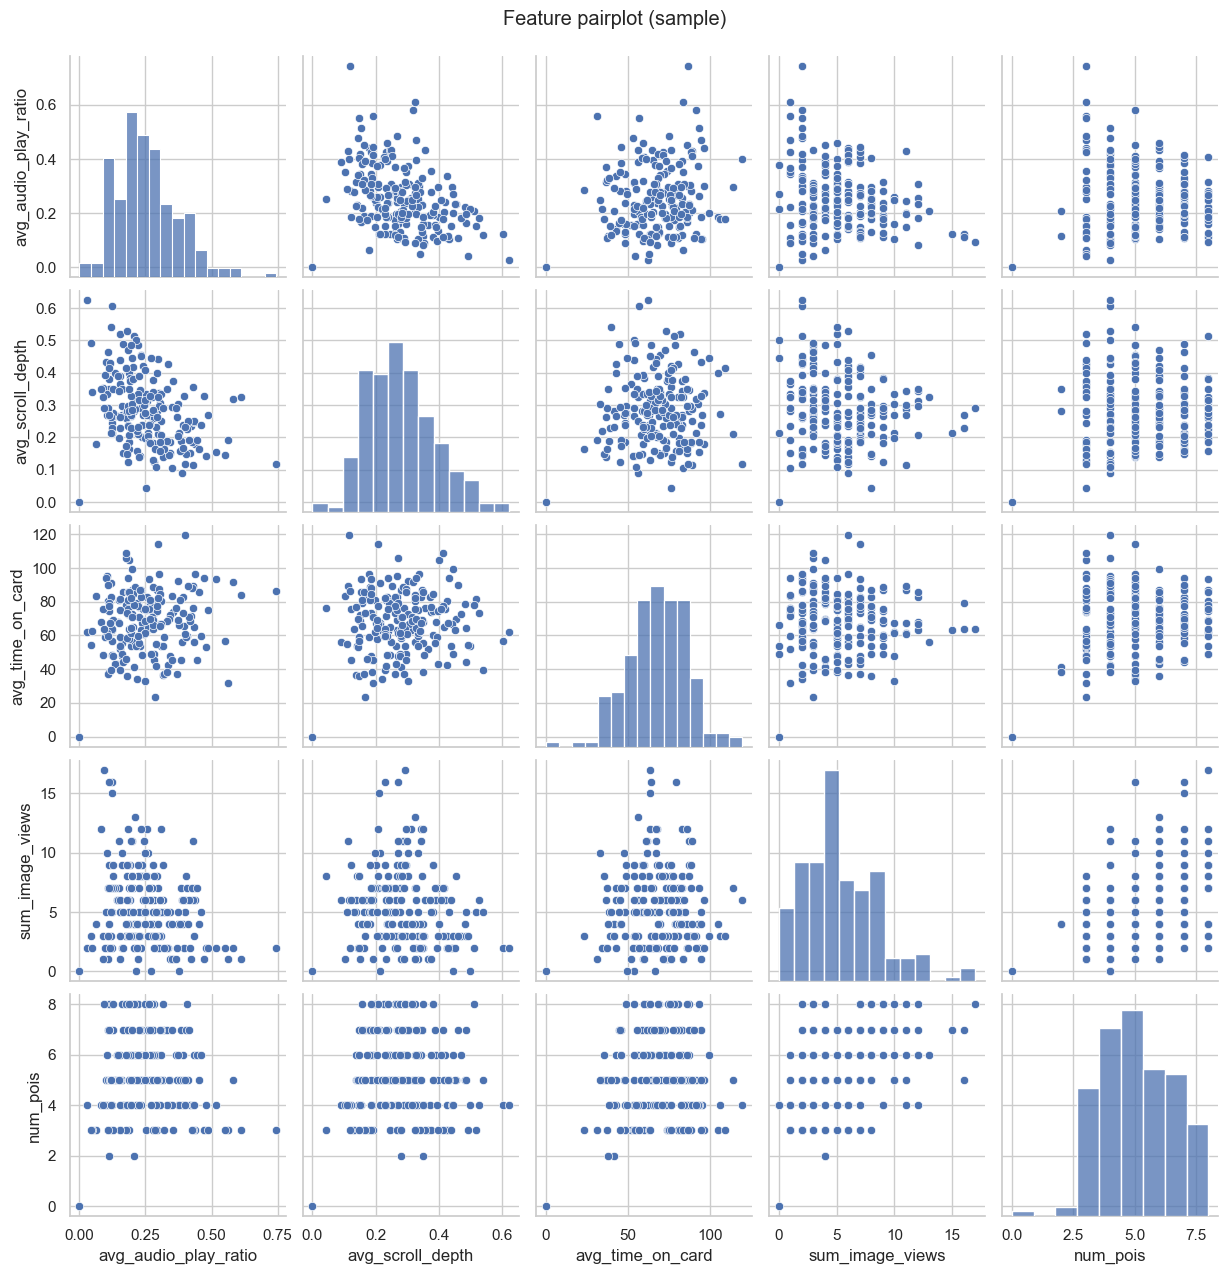

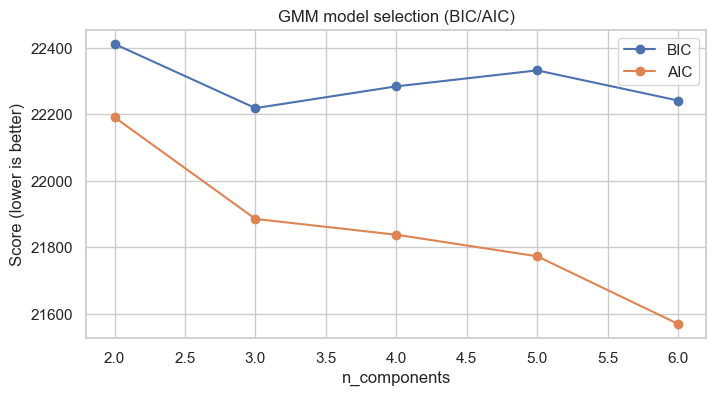

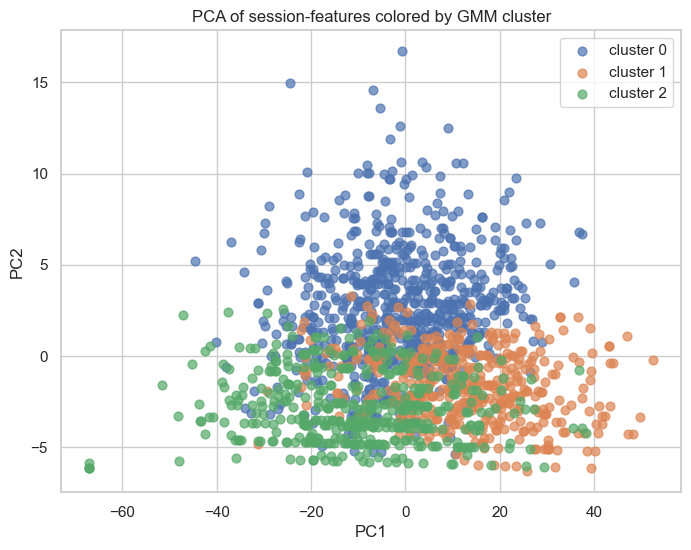

In [7]:
# Cell 7 — PCA projection colored by GMM hard labels
pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(X)
plt.figure(figsize=(8,6))
palette = sns.color_palette("deep", n_colors=best_k)
for lab in sorted(set(hard_labels)):
    mask = (hard_labels == lab)
    plt.scatter(Z[mask,0], Z[mask,1], label=f'cluster {lab}', alpha=0.7, s=40)
plt.legend()
plt.title('PCA of session-features colored by GMM cluster')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.show()


In [8]:
# Cell 8 — classifier to predict gmm_label from features
y = df['gmm_label'].values
Xf = df[feats].fillna(0).values

# train/test split stratified by label
X_train, X_test, y_train, y_test = train_test_split(Xf, y, test_size=0.2, random_state=42, stratify=y if len(set(y))>1 else None)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

# Evaluate on test
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 (macro):", f1_score(y_test, y_pred, average='macro'))
print("\nClassification report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9559748427672956
F1 (macro): 0.9551017272112606

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96       144
           1       0.94      0.92      0.93        86
           2       0.98      0.98      0.98        88

    accuracy                           0.96       318
   macro avg       0.96      0.95      0.96       318
weighted avg       0.96      0.96      0.96       318



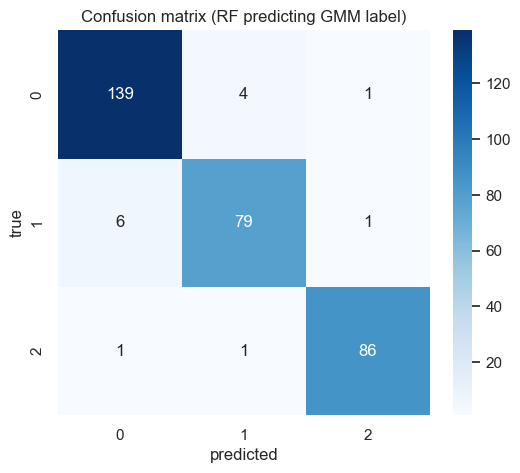

avg_audio_play_ratio 0.158
avg_scroll_depth 0.1183
avg_time_on_card 0.2091
sum_image_views 0.2309
num_pois 0.2837


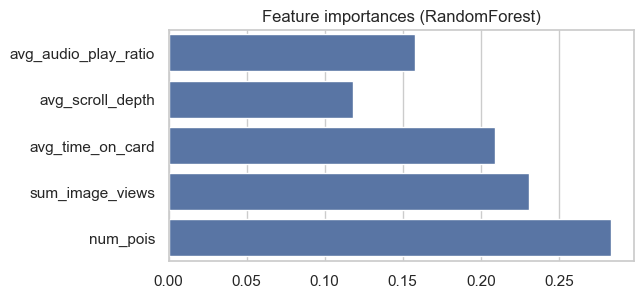

In [9]:
# Cell 9 — confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion matrix (RF predicting GMM label)')
plt.xlabel('predicted'); plt.ylabel('true')
plt.show()

# Feature importances
importances = clf.feature_importances_
for f, imp in zip(feats, importances):
    print(f, round(imp,4))
# bar plot
plt.figure(figsize=(6,3))
sns.barplot(x=importances, y=feats)
plt.title('Feature importances (RandomForest)')
plt.show()


In [10]:
# Cell 10 — cross-validation scores (stratified)
if len(set(y)) > 1:
    cv = StratifiedKFold(n_splits=min(5, len(df)))  # avoid >samples
    scores = cross_val_score(clf, Xf, y, cv=cv, scoring='f1_macro')
    print("Cross-val F1_macro:", scores, "mean:", scores.mean())
else:
    print("Single label present; can't do stratified CV.")


Cross-val F1_macro: [0.92980103 0.93101931 0.94731502 0.94530391 0.90496411] mean: 0.9316806741561244


In [11]:
# Cell 11 — persist models for later use
dump(gmm, MODEL_DIR / 'gmm_profiles.joblib')
dump(clf, MODEL_DIR / 'rf_profile_classifier.joblib')
print("Saved models to", MODEL_DIR)

# Save feature names and metadata for frontend export if needed
meta = {'feats': feats, 'gmm_components': int(best_k)}
with open(MODEL_DIR / 'model_meta.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2)
print("Saved model metadata.")


Saved models to /Users/suryavardhanchaluvadi/Library/CloudStorage/OneDrive-Amritavishwavidyapeetham/B.Tech/Sem 5/ML/ML_hackathon/backend/backend/models
Saved model metadata.


In [12]:
# Cell 12 — Inspect cluster centroids (means) to label clusters manually
gmm_means = gmm.means_  # shape (k, len(feats))
centroid_df = pd.DataFrame(gmm_means, columns=feats)
centroid_df.index.name = 'cluster'
display(centroid_df)

# Based on these numbers, you can map e.g.:
# cluster 0 -> "visual", cluster 1 -> "auditory", cluster 2 -> "textual"
# and create a small mapping
cluster_to_profile = {i: f"profile_{i}" for i in range(centroid_df.shape[0])}
print("Example mapping (edit manually):", cluster_to_profile)

# Save mapping
with open(MODEL_DIR / 'cluster_to_profile.json', 'w', encoding='utf-8') as f:
    json.dump(cluster_to_profile, f, indent=2)


,avg_audio_play_ratio,avg_scroll_depth,avg_time_on_card,sum_image_views,num_pois
cluster,,,,,
0,0.232297,0.264611,65.624292,7.698495,6.190011
1,0.312183,0.266861,77.487470,4.213558,5.396667
2,0.252048,0.309253,57.615125,3.019222,3.592068


Example mapping (edit manually): {0: 'profile_0', 1: 'profile_1', 2: 'profile_2'}
